In [1]:
!git clone https://github.com/mohamed-ladjal-AI/medical-image-segmentation-benchmark.git
%cd medical-image-segmentation-benchmark
!pip install -r requirements.txt


fatal: destination path 'medical-image-segmentation-benchmark' already exists and is not an empty directory.
/content/medical-image-segmentation-benchmark


In [ ]:
!python run_benchmark.py --model unet --epochs 1 --batch_size 16 --seed 123 --split_file dataset/splits/split_seed_123.json

2026-05-19 10:34:22.880078: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
🖥️  Using Execution Device: cuda
/content/medical-image-segmentation-benchmark/src/data_augmentation.py:16: UserWarning: Argument(s) 'mode' are not valid for transform Affine
  A.Affine(translate_percent=0.05, scale=(0.95, 1.05), rotate=15, p=affine_p, mode=0),
🔁 Loaded existing train/val split from dataset/splits/split_seed_123.json
👁️ Found 444 valid raw ultrasound frames in: dataset/train
👁️ Found 49 valid raw ultrasound frames in: dataset/train
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than 

In [4]:
!python tune_hyperparameters.py --model unet_plus_plus --n_trials 20 --epochs 10 --batch_size 8

python3: can't open file '/content/medical-image-segmentation-benchmark/tune_hyperparameters.py': [Errno 2] No such file or directory


In [ ]:
# Re-install poppler-utils
!apt-get update && apt-get install -y poppler-utils

# Now, let's re-run the diagnostic cell to confirm the installation and try displaying the PDF again.

--- Diagnostic Steps ---
1. Verifying 'poppler-utils' package installation:
Package: poppler-utils
Status: install ok installed
Priority: optional
Section: utils
Installed-Size: 681
Maintainer: Ubuntu Developers <ubuntu-devel-discuss@lists.ubuntu.com>
Architecture: amd64
Multi-Arch: foreign
Source: poppler
Version: 22.02.0-2ubuntu0.12
Replaces: pdftohtml, xpdf-reader, xpdf-utils (<< 3.02-2~)
Provides: pdftohtml, xpdf-utils
Depends: libpoppler118 (= 22.02.0-2ubuntu0.12), libc6 (>= 2.34), libcairo2 (>= 1.12.0), libfreetype6 (>= 2.2.1), liblcms2-2 (>= 2.2+git20110628), libstdc++6 (>= 5.2)
Breaks: xpdf-common, xpdf-utils (<< 1:0)
Conflicts: pdftohtml
Description: PDF utilities (based on Poppler)
 Poppler is a PDF rendering library based on Xpdf PDF viewer.
 .
 This package contains command line utilities (based on Poppler) for getting
 information of PDF documents, convert them to other formats, or manipulate
 them:
  * pdfdetach -- lists or extracts embedded files (attachments)
  * pdffon

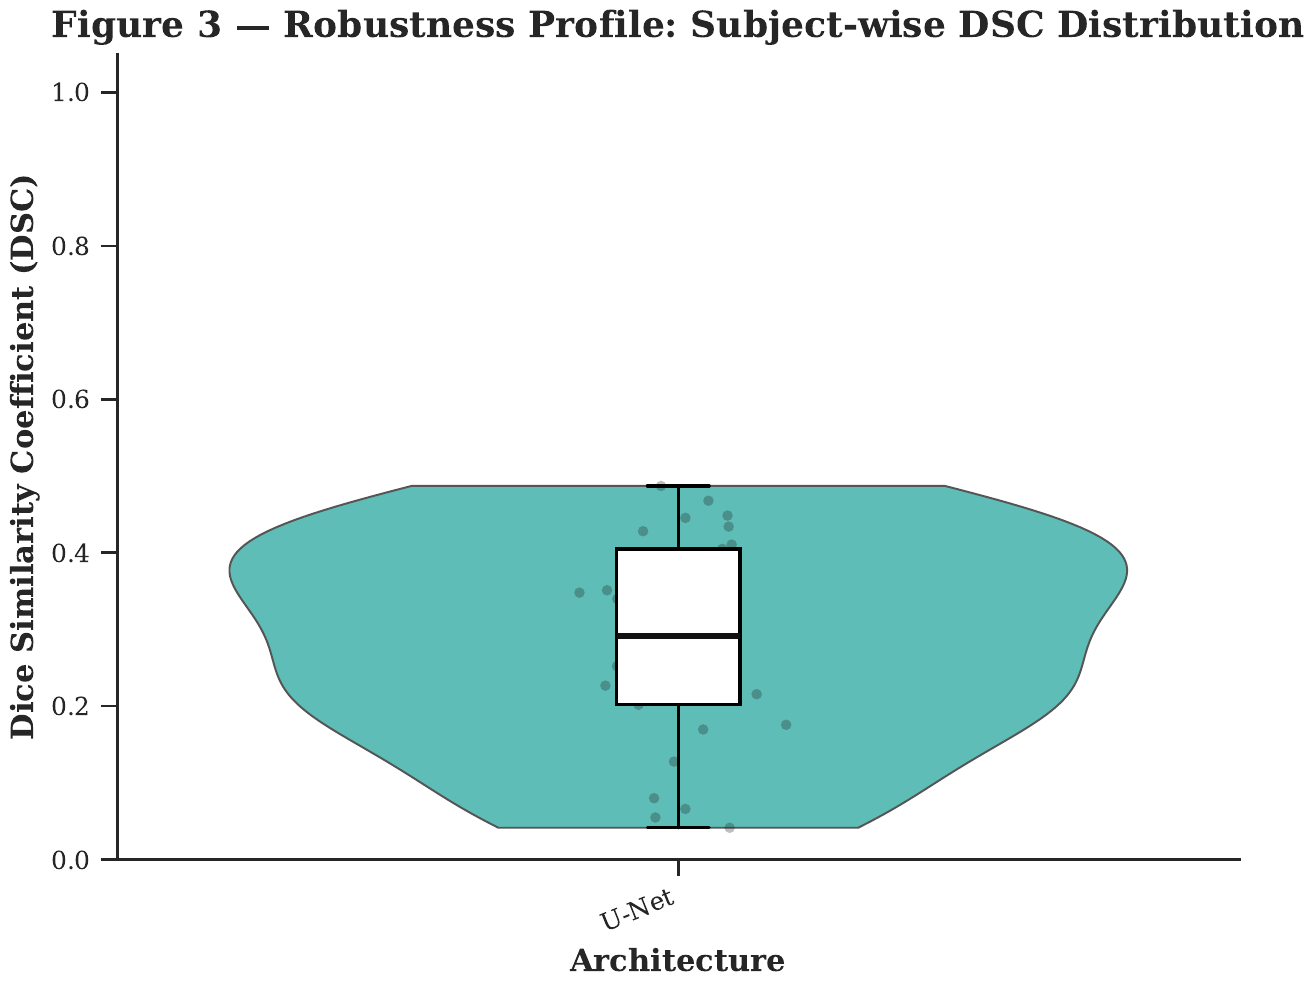

In [21]:
import os
from pdf2image import convert_from_path
from IPython.display import display, Image

print("--- Diagnostic Steps ---")

# 1. Verify poppler-utils package installation
print("1. Verifying 'poppler-utils' package installation:")
!dpkg -s poppler-utils

# 2. Check if pdftoppm executable exists and its permissions
print("\n2. Checking for 'pdftoppm' executable in /usr/bin:")
!ls -l /usr/bin/pdftoppm

# 3. Explicitly add /usr/bin to the PATH for the current process
print("\n3. Adding /usr/bin to os.environ['PATH']:")
if '/usr/bin' not in os.environ['PATH'].split(os.pathsep):
    os.environ['PATH'] += os.pathsep + '/usr/bin'
    print(f"Updated PATH: {os.environ['PATH']}")
else:
    print(f"/usr/bin already in PATH: {os.environ['PATH']}")

# 4. Re-check if pdftoppm is now discoverable via 'which'
print("\n4. Re-checking 'which pdftoppm' after PATH update:")
!which pdftoppm

# 5. Attempt PDF conversion again with explicit poppler_path
print("\n5. Attempting PDF conversion with poppler_path='/usr/bin':")
POPPLER_PATH = '/usr/bin'
robustness_profile_path = 'experiments/unet_20260519_101339_seed123_20260519_101339/plots/fig3_robustness_profile.pdf'

try:
    images = convert_from_path(robustness_profile_path, last_page=1, poppler_path=POPPLER_PATH)
    if images:
        print("Successfully converted PDF. Displaying first page:")
        display(images[0])
    else:
        print("Could not convert robustness profile PDF after diagnostics.")
except Exception as e:
    print(f"Error displaying robustness profile after diagnostics: {e}")